In [17]:
import numpy as np
from numba import njit
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation
from scipy.integrate import solve_ivp
from eigenshuffle import eigenshuffle_eig
import numpy as np
from scipy.optimize import linear_sum_assignment
import scienceplots

def track_eigenvalues(all_evals, weight_real=1.0, weight_imag=10.0):
    T, N = all_evals.shape
    tracked_eigvals = np.zeros((T, N), dtype=np.complex128)
    
    # --- Paso t=0 ---
    idx_0 = np.argsort(all_evals[0].imag)
    tracked_eigvals[0] = all_evals[0][idx_0]
    
    # --- Pasos t > 0 ---
    for t in range(1, T):
        prev_eigs = tracked_eigvals[t-1]
        curr_eigs = all_evals[t]
        
        # 1. ¡CORRECCIÓN AQUÍ! prev_eigs son las filas (eje 0), curr_eigs las columnas (eje 1)
        diff = prev_eigs[:, None] - curr_eigs[None, :]
        
        # Distancias al cuadrado
        dist_real = np.abs(diff.real)**2
        dist_imag = np.abs(diff.imag)**2
        
        # 2. Matriz de Coste Mixta
        cost_matrix = (weight_real * dist_real) + (weight_imag * dist_imag)
        
        # 3. Asignación (Algoritmo Húngaro)
        _, col_ind = linear_sum_assignment(cost_matrix)
        
        # 4. Guardar resultado (Ahora sí aplicará el orden correctamente)
        tracked_eigvals[t] = curr_eigs[col_ind]
        
    return tracked_eigvals

@njit(fastmath=True)
def hopfield(STEPS, W, X_0, DT):
    DIM = X_0.shape[0]
    X_time_series = np.zeros((STEPS, DIM))
    X_time_series[0] = X_0
    for t in range(1, STEPS):
        if t % 10 == 0:
            print(f"Paso {t}/{STEPS}")
        for i in range(DIM):
            sum = 0
            for j in range(DIM):
                sum += W[i, j] * X_time_series[t-1, j]

            X_time_series[t, i] = np.tanh(sum)
    
    return X_time_series

def ODE_system(t, y, dim, alpha):
    X = y[:dim]
    W = y[dim:].reshape((dim, dim))

    dim = np.shape(X)[0]
    dWdt = alpha * (np.eye(dim) - np.outer(X, X))
    dXdt = W @ X

    return np.concatenate([dXdt, dWdt.flatten()])

def track_eigen_complete_inertia(all_evals, all_evecs, alpha=0.1):
    """
    all_evals: array de dimensiones (T, N) con los autovalores precalculados.
    all_evecs: array de dimensiones (T, N, N) con los autovectores.
    """
    T, N = all_evals.shape
    tracked_evals = np.zeros((T, N), dtype=np.complex128)
    tracked_evecs = np.zeros((T, N, N), dtype=np.complex128)
    
    if T == 0:
        return tracked_evals, tracked_evecs
        
    idx_0 = np.argsort(all_evals[0].imag)
    tracked_evals[0] = all_evals[0][idx_0]
    tracked_evecs[0] = all_evecs[0][:, idx_0]
    
    if T == 1:
        return tracked_evals, tracked_evecs

    curr_evals = all_evals[1]
    prev_evals = tracked_evals[0]
    cost_matrix = np.abs(prev_evals[:, None] - curr_evals[None, :])
    _, col_ind = linear_sum_assignment(cost_matrix)
    tracked_evals[1] = curr_evals[col_ind]
    tracked_evecs[1] = all_evecs[1][:, col_ind]

    for t in range(2, T):
        curr_evals = all_evals[t]
        velocidad = tracked_evals[t-1] - tracked_evals[t-2]
        prediccion = tracked_evals[t-1] + velocidad
        
        curr_evecs = all_evecs[t]
        prev_evecs = tracked_evecs[t-1]

        # 1. Distancia pura de autovalores (sin normalización)
        cost_evals = np.abs(prediccion[:, None] - curr_evals[None, :])

        # 2. Proyección bi-ortogonal estricta (Autovectores Izquierdos x Derechos)
        L_prev = np.linalg.inv(prev_evecs)
        proyecciones = np.abs(L_prev @ curr_evecs)
        cost_evecs = 1.0 - proyecciones
        if t==50:
            print(cost_evecs)

        # 3. Matriz combinada
        cost_matrix = alpha * cost_evals + (1 - alpha) * cost_evecs

        _, col_ind = linear_sum_assignment(cost_matrix)        
        
        tracked_evals[t] = curr_evals[col_ind]
        tracked_evecs[t] = all_evecs[t, :, col_ind]
        
    return tracked_evals, tracked_evecs

def track_eigen_inertia(all_evals, all_evecs):
    """
    Ordena autovalores y autovectores a lo largo del tiempo basándose EXCLUSIVAMENTE
    en la inercia (predicción lineal) de la trayectoria de los autovalores.
    
    all_evals: array (T, N) de autovalores complejos.
    all_evecs: array (T, N, N) de autovectores complejos.
    """
    T, N = all_evals.shape
    tracked_evals = np.zeros((T, N), dtype=np.complex128)
    tracked_evecs = np.zeros((T, N, N), dtype=np.complex128)
    
    if T == 0:
        return tracked_evals, tracked_evecs
        
    # --- Paso t=0: Ordenar por parte imaginaria ---
    idx_0 = np.argsort(all_evals[0].imag)
    tracked_evals[0] = all_evals[0][idx_0]
    tracked_evecs[0] = all_evecs[0][:, idx_0]
    
    if T == 1:
        return tracked_evals, tracked_evecs

    # --- Paso t=1: Distancia pura (sin inercia aún) ---
    curr_evals = all_evals[1]
    prev_evals = tracked_evals[0]
    
    cost_matrix = np.abs(prev_evals[:, None] - curr_evals[None, :])
    _, col_ind = linear_sum_assignment(cost_matrix)
    
    tracked_evals[1] = curr_evals[col_ind]
    tracked_evecs[1] = all_evecs[1][:, col_ind]

    # --- Pasos t >= 2: Inercia / Predicción Lineal ---
    for t in range(2, T):
        curr_evals = all_evals[t]
        
        # 1. Calcular la velocidad (delta) del paso anterior
        velocidad = tracked_evals[t-1] - tracked_evals[t-2]
        
        # 2. Predecir la posición esperada en el paso actual
        prediccion = tracked_evals[t-1] + velocidad
        
        # 3. Matriz de costo: Distancia entre la PREDICCIÓN y los valores ACTUALES
        cost_matrix = np.abs(prediccion[:, None] - curr_evals[None, :])
        
        # 4. Asignación óptima con el algoritmo húngaro
        _, col_ind = linear_sum_assignment(cost_matrix)        
        
        # 5. Guardar los resultados ordenados
        tracked_evals[t] = curr_evals[col_ind]
        tracked_evecs[t] = all_evecs[t, :, col_ind]
        
    return tracked_evals, tracked_evecs

## Figura de estabilidad de autovalores

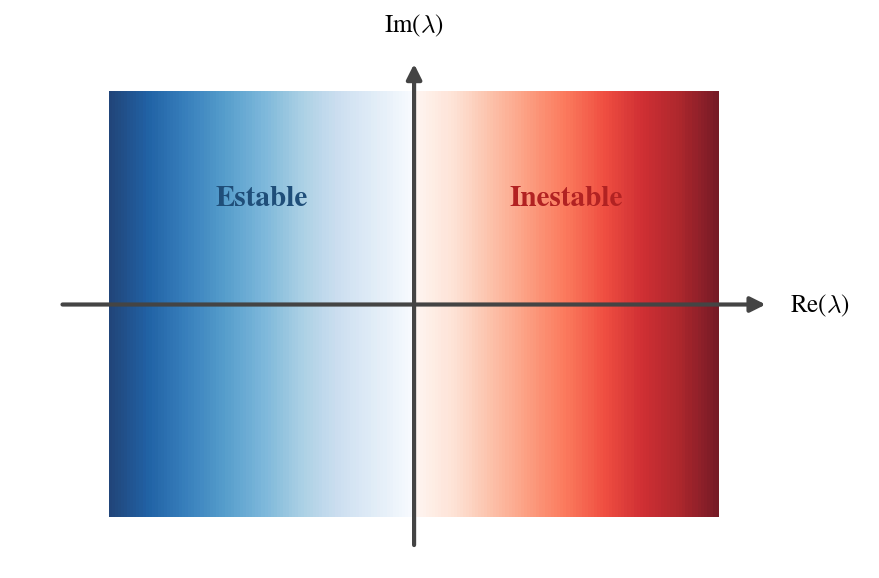

In [ ]:

# 1. Inicializar la figura con alta resolución para impresión (DPI alto)
fig, ax = plt.subplots(figsize=(6, 4), dpi=150)

# 2. Crear el degradado de fondo
# Lado izquierdo (Estable - Azul) que se desvanece al acercarse a 0
grid_left = np.tile(np.linspace(1, 0, 100), (100, 1))
ax.imshow(grid_left, cmap='Blues', extent=[-3, 0, -2, 2], alpha=0.9, aspect='auto')

# Lado derecho (Inestable - Rojo) que aparece a partir de 0
grid_right = np.tile(np.linspace(0, 1, 100), (100, 1))
ax.imshow(grid_right, cmap='Reds', extent=[0, 3, -2, 2], alpha=0.9, aspect='auto')

# 3. Dibujar los ejes personalizados con flechas en las puntas
# Eje Horizontal (Real)
ax.annotate('', xy=(3.5, 0), xytext=(-3.5, 0),
            arrowprops=dict(arrowstyle="-|>", color="#444444", lw=2, mutation_scale=15))
# Eje Vertical (Imaginario)
ax.annotate('', xy=(0, 2.3), xytext=(0, -2.3),
            arrowprops=dict(arrowstyle="-|>", color="#444444", lw=2, mutation_scale=15))

# 4. Añadir las etiquetas matemáticas de los ejes
ax.text(3.7, 0, r'Re($\lambda$)', va='center', ha='left', fontsize=12)
ax.text(0, 2.5, r'Im($\lambda$)', va='bottom', ha='center', fontsize=12)

# 5. Añadir los textos "Stable" y "Unstable" con sus respectivos colores
ax.text(-1.5, 1, 'Estable', color='#1f4e79', fontsize=14, ha='center', va='center', weight='bold')
ax.text(1.5, 1, 'Inestable', color='#b22222', fontsize=14, ha='center', va='center', weight='bold')

# 6. Limpieza estética: Ocultar los bordes y marcas por defecto de matplotlib
for spine in ax.spines.values():
    spine.set_visible(False)
ax.set_xticks([])
ax.set_yticks([])

# Configurar límites estrictos de la vista para que no se corte nada
ax.set_xlim(-4, 4.5)
ax.set_ylim(-2.5, 2.8)

plt.tight_layout()
plt.show()

## Evolución de autovalores

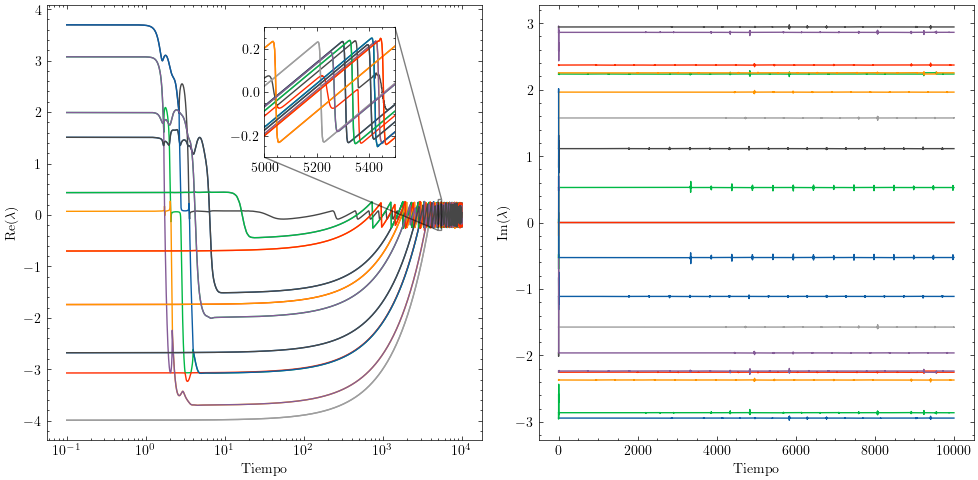

In [3]:
dim = 20
time = 10000
t_eval = np.logspace(-1, 4, 150000)
alpha = 0.001

rng_X = np.random.default_rng(42)
rng_W = np.random.default_rng(69)

X_0 = rng_X.normal(loc=0, scale=1/np.sqrt(dim), size=dim)
W_0 = rng_W.normal(loc=0, scale=1, size=(dim, dim))

y_0 = np.concatenate([X_0, W_0.flatten()])
solution = solve_ivp(ODE_system, [0, time], y0=y_0, args=[dim, alpha], t_eval=t_eval, method='DOP853')

X = solution.y[:dim, :].transpose()
W = solution.y[dim:, :].reshape((dim, dim, -1)).transpose(2, 0, 1)

# eigenvalues = track_eigenvalues(W)
eigenvalues = np.linalg.eigvals(W)
eigenvalues = track_eigenvalues(eigenvalues, weight_real=1, weight_imag=10)

plt.style.use(['science'])

fig, ax = plt.subplots(ncols=2, figsize=(10, 5))
ax[0].semilogx(t_eval, eigenvalues.real, lw=1, rasterized=True)
ax[1].plot(t_eval, eigenvalues.imag, lw=1, rasterized=True)
ax[0].set_box_aspect(1)
ax[1].set_box_aspect(1)

# Inset axes
axins = ax[0].inset_axes([0.5, 0.65, 0.3, 0.3], xlim=[5000, 5500], ylim=[-0.3, 0.3])
axins.plot(t_eval, eigenvalues.real, lw=1)
ax[0].indicate_inset_zoom(axins, edgecolor='black')

# Títulos y texto
ax[0].set_xlabel("Tiempo")
ax[0].set_ylabel(r"Re$(\lambda)$")

ax[1].set_xlabel("Tiempo")
ax[1].set_ylabel(r"Im$(\lambda)$")

plt.tight_layout()

plt.savefig("Figures/Evolucion coloreada.pdf")
plt.show()

# W_norm = np.linalg.norm(W, axis=(1, 2))
# X_norm = np.linalg.norm(X, axis=1)

# y = X_norm**2
# y_dotdot = np.gradient(np.gradient(y, t_eval), t_eval)

# plt.plot(y_dotdot, y, 'b.', ms=1)
# plt.show()

# V = 0.5 * W_norm**2 + alpha * (0.5 * X_norm**2 - np.log(X_norm))
# dVdt = (np.trace(W, axis1=1, axis2=2) - np.einsum('ti, tij, tj -> t', X, W, X)/X_norm**2)
# V_dot = np.gradient(V, t_eval)

# plt.plot(t_eval, (V - V.mean())/(V.max()-V.min()), label='Lyapunov function')
# plt.plot(t_eval, (V_dot - V_dot.mean())/(V_dot.max()-V_dot.min()), label=r"$\frac{dV}{dt}$ numérica", alpha=0.8)
# plt.plot(t_eval, (dVdt - dVdt.mean())/(dVdt.max()-dVdt.min()), label=r"$\frac{dV}{dt}$ analítica", alpha=0.8)
# plt.legend()
# plt.show()

# print("X: ", X.shape)
# print("W: ", W.shape)
# WX = np.einsum('tij, tj -> ti', W, X)
# WX_norm = np.linalg.norm(WX, axis=1)
# X_norm = np.linalg.norm(X, axis=1)

# W_spectral_norm = np.linalg.norm(W, ord=2, axis=(1, 2))

# plt.plot(WX_norm, label=r"$|WX|$")
# plt.plot(W_norm * X_norm/2, label=r"$|W||X|$")
# # plt.plot(W_spectral_norm * X_norm, label=r"$\sigma_{max}(W)|X|$")
# plt.legend()
# plt.show()



## Circular Law

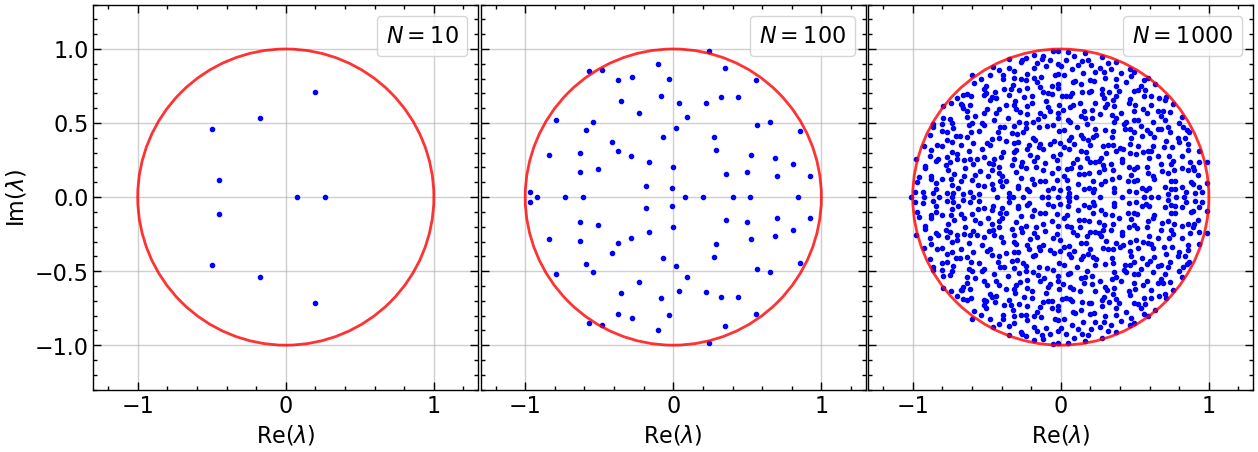

In [33]:
from matplotlib.patches import Circle
dims = [10, 100, 1000]

matrices = [np.random.standard_normal((dim, dim)) for dim in dims]

autovalores = [np.linalg.eigvals(matrix) for matrix in matrices]

plt.style.use(['science', 'notebook'])

fig, ax = plt.subplots(ncols=3, figsize=(15, 5), sharey=True, gridspec_kw={'wspace': 0})

for i in range(3):
    autovalores[i] = autovalores[i]/np.sqrt(dims[i])
    ax[i].plot(autovalores[i].real, autovalores[i].imag, 'b.', label=fr"$N = {dims[i]}$")
    ax[i].set_aspect('equal')
    ax[i].set_xlabel(r"Re$(\lambda)$")
    circle = Circle([0, 0], 1.0, edgecolor='red', fill=False, linewidth=2, zorder=5, alpha=0.8)
    ax[i].add_patch(circle)
    ax[i].grid(True, alpha=0.6)
    ax[i].set_xlim(-1.3, 1.3)
    ax[i].set_ylim(-1.3, 1.3)
    ax[i].legend(frameon=True, markerscale=0, handletextpad=0, handlelength=0)
    if i > 0:
        ax[i].tick_params(labelleft=False)
ax[0].set_ylabel(r"Im$(\lambda)$")

plt.savefig("Figures/circular law.pdf")
plt.show()

## Excitación de modos

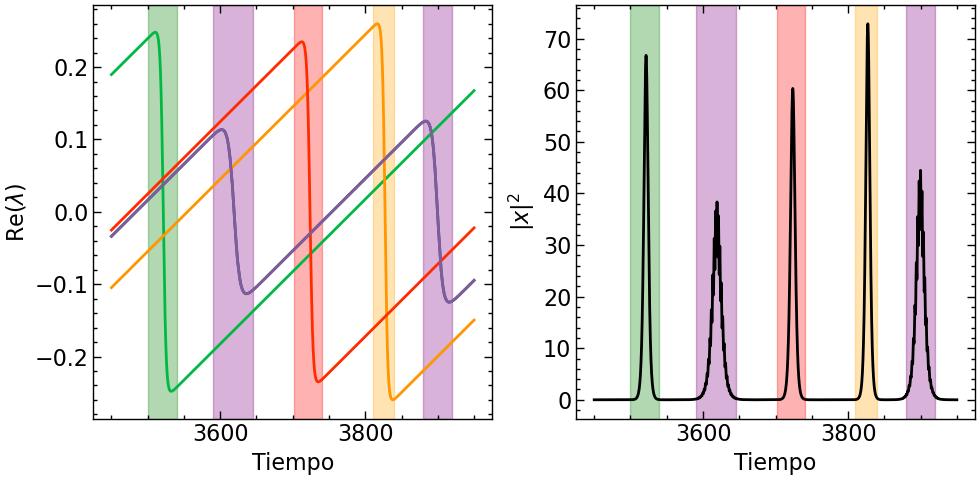

[-0.09480991-1.58332644j  0.16740932+0.j         -0.14963851+0.j
 -0.02225634+0.j         -0.09480991+1.58332644j]


In [40]:
dim = 5
rng_W = np.random.default_rng(42)
rng_X = np.random.default_rng(42)
time = 4000
alpha = 0.001
t_eval = np.linspace(3450, 3950, 10000)

W_0 = rng_W.standard_normal((dim, dim))
X_0= rng_X.standard_normal(dim)

y_0 = np.concatenate([X_0, W_0.flatten()])
solution = solve_ivp(ODE_system, [0, time], y0=y_0, args=[dim, alpha], t_eval=t_eval, method='DOP853')

X = solution.y[:dim, :].transpose()
W = solution.y[dim:, :].reshape((dim, dim, -1)).transpose(2, 0, 1)

X_norm = np.linalg.norm(X, axis=1)**2

eigenvalues = np.linalg.eigvals(W)

eigenvalues = track_eigen_inertia(eigenvalues)

plt.style.use(['science', 'notebook'])
fig, ax = plt.subplots(ncols=2, figsize=(10, 5))

ax[0].plot(t_eval, eigenvalues.real)
ax[0].set_xlabel("Tiempo")
ax[0].set_ylabel(r"Re$(\lambda)$")
ax[0].axvspan(xmin=3500, xmax=3540, color='green', alpha=0.3)
ax[0].axvspan(xmin=3590, xmax=3645, color='purple', alpha=0.3)
ax[0].axvspan(xmin=3702, xmax=3740, color='red', alpha=0.3)
ax[0].axvspan(xmin=3810, xmax=3840, color='orange', alpha=0.3)
ax[0].axvspan(xmin=3880, xmax=3920, color='purple', alpha=0.3)

ax[1].plot(t_eval, X_norm, c='k')
ax[1].set_xlabel("Tiempo")
ax[1].set_ylabel(r"$|x|^2$")
ax[1].axvspan(xmin=3500, xmax=3540, color='green', alpha=0.3)
ax[1].axvspan(xmin=3590, xmax=3645, color='purple', alpha=0.3)
ax[1].axvspan(xmin=3702, xmax=3740, color='red', alpha=0.3)
ax[1].axvspan(xmin=3810, xmax=3840, color='orange', alpha=0.3)
ax[1].axvspan(xmin=3880, xmax=3920, color='purple', alpha=0.3)

plt.tight_layout()
plt.savefig("Figures/Picos.pdf")
plt.show()

print(eigenvalues[-1])


## Modelo de Hopfield

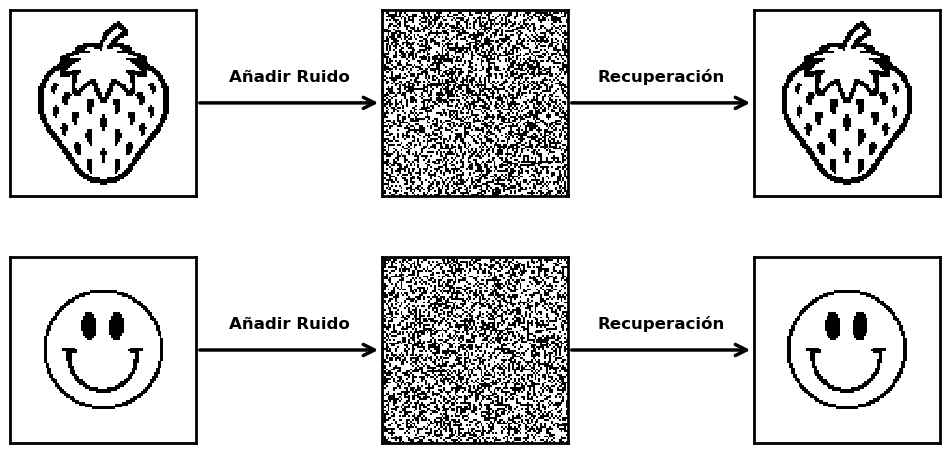

In [59]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation
from PIL import Image
from matplotlib.patches import ConnectionPatch

def preparar_vector_hopfield(ruta_imagen, tamano=32, umbral=127, invertir=False):
    """
    Convierte una imagen PNG/JPG en una matriz cuadrada de 1s y -1s.
    
    :param ruta_imagen: Ruta del archivo (ej. 'numero3.png')
    :param tamano: El ancho/alto de la matriz cuadrada (ej. 32 para una matriz de 32x32)
    :param umbral: Valor (0-255) para decidir qué es "blanco" y qué es "negro"
    :param invertir: Si es True, el fondo blanco se vuelve -1 y el dibujo negro se vuelve 1
    """
    # 1. Abrir la imagen y convertirla a escala de grises ('L')
    img = Image.open(ruta_imagen).convert('L')
    
    # 2. Redimensionar a una matriz cuadrada (tamano x tamano)
    img = img.resize((tamano, tamano))
    
    # 3. Convertir a un array de NumPy
    img_array = np.array(img)
    
    # 4. Binarizar a 1 y -1 basado en el umbral
    if invertir:
        # Píxeles oscuros (< umbral) se vuelven 1, claros se vuelven -1
        matriz_hopfield = np.where(img_array < umbral, 1, -1)
    else:
        # Píxeles claros (> umbral) se vuelven 1, oscuros se vuelven -1
        matriz_hopfield = np.where(img_array > umbral, 1, -1)
        
    return matriz_hopfield.flatten()


def add_annotated_arrow(ax_start, ax_end, text):
    """
    Dibuja una flecha entre dos ejes y coloca un texto sobre ella.
    """
    # 1. Definir los puntos de conexión. 'axes fraction' usa coordenadas de 0 a 1 dentro del eje.
    # Conectamos desde el centro del borde derecho del eje inicial (1.02, 0.5)
    # hasta el centro del borde izquierdo del eje final (-0.02, 0.5)
    xy_start = (1.02, 0.5) 
    xy_end = (-0.02, 0.5)
    
    # 2. Crear la flecha usando ConnectionPatch
    arrow = ConnectionPatch(xyA=xy_start, xyB=xy_end, coordsA="axes fraction", coordsB="axes fraction",
                            axesA=ax_start, axesB=ax_end,
                            arrowstyle="->", color="black", linewidth=2.5, mutation_scale=20)
    # mutation_scale hace la punta de la flecha más grande y visible
    ax_end.add_artist(arrow) # Se añade a uno de los ejes, no importa cuál

    # 3. Colocar el texto sobre la flecha. 
    # Calculamos el punto medio entre los dos ejes en coordenadas de figura para posicionar el texto.
    bbox_start = ax_start.get_position()
    bbox_end = ax_end.get_position()
    mid_x = (bbox_start.x1 + bbox_end.x0) / 2
    mid_y = (bbox_start.y0 + bbox_start.y1) / 2
    
    # Añadir el texto con fig.text
    fig.text(mid_x, mid_y + 0.03, text, ha='center', va='bottom', fontsize=12, color='black', fontweight='bold')

L = 100

vector_fresa = preparar_vector_hopfield("fresa.png", tamano=L, invertir=True)
vector_cara = preparar_vector_hopfield("smiley.jpg", tamano=L, invertir=True)

X_0_fresa = np.sign(5 * np.random.standard_normal(L * L) + vector_fresa)
X_0_cara = np.sign(5 * np.random.standard_normal(L * L) + vector_cara)

W = 0.5 * (np.outer(vector_cara, vector_cara) + np.outer(vector_fresa, vector_fresa))

X_fresa = np.sign(W @ X_0_fresa)
X_cara= np.sign(W @ X_0_cara)

fig, ax = plt.subplots(2, 3, figsize=(12, 6), gridspec_kw={'wspace': 1.0, 'hspace': 0.15})


data = [[np.reshape(vector_fresa, (L, L)), np.reshape(X_0_fresa, (L, L)), np.reshape(X_fresa, (L, L))], 
        [np.reshape(vector_cara, (L, L)), np.reshape(X_0_cara, (L, L)), np.reshape(X_cara, (L, L))]]
for i in range(2):
    for j in range(3):
        ax[i, j].imshow(data[i][j], cmap='Grays', vmin=-1, vmax=1, interpolation='none')
        ax[i, j].set_xticks([])
        ax[i, j].set_yticks([])
        for spine in ax[i, j].spines.values():
            spine.set_visible(True)
            spine.set_edgecolor('black')
            spine.set_linewidth(2)

# --- APLICAR LAS ANOTACIONES ---
# Fila 1 (Fresa)
add_annotated_arrow(ax[0, 0], ax[0, 1], "Añadir Ruido")
add_annotated_arrow(ax[0, 1], ax[0, 2], "Recuperación")

# Fila 2 (Cara)
add_annotated_arrow(ax[1, 0], ax[1, 1], "Añadir Ruido")
add_annotated_arrow(ax[1, 1], ax[1, 2], "Recuperación")

plt.savefig("Figures/Hopfield.pdf")
plt.show()




## Distribución de autovalores en la colectividad de Ginibre

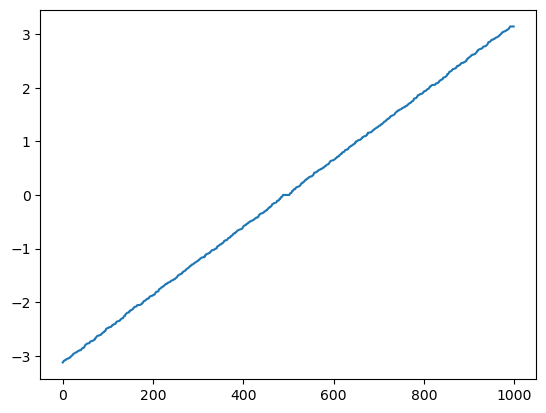

In [5]:
import numpy as np
import matplotlib.pyplot as plt

N = 1000

W = np.random.normal(0, 1/np.sqrt(N), (N, N))

eigenvalues = np.linalg.eigvals(W)

phases = np.angle(eigenvalues)

plt.plot(np.sort(phases))

plt.show()

## $|x|^2$ para diferentes tamaños del sistema


--- Iniciando N = 1 ---
Paso 40000 / 400000
Paso 80000 / 400000
Paso 120000 / 400000
Paso 160000 / 400000
Paso 200000 / 400000
Paso 240000 / 400000
Paso 280000 / 400000
Paso 320000 / 400000
Paso 360000 / 400000
N = 1 simulado, procesando gráfica...

--- Iniciando N = 10 ---
Paso 40000 / 400000
Paso 80000 / 400000
Paso 120000 / 400000
Paso 160000 / 400000
Paso 200000 / 400000
Paso 240000 / 400000
Paso 280000 / 400000
Paso 320000 / 400000
Paso 360000 / 400000
N = 10 simulado, procesando gráfica...

--- Iniciando N = 100 ---
Paso 40000 / 400000
Paso 80000 / 400000
Paso 120000 / 400000
Paso 160000 / 400000
Paso 200000 / 400000
Paso 240000 / 400000
Paso 280000 / 400000
Paso 320000 / 400000
Paso 360000 / 400000
N = 100 simulado, procesando gráfica...


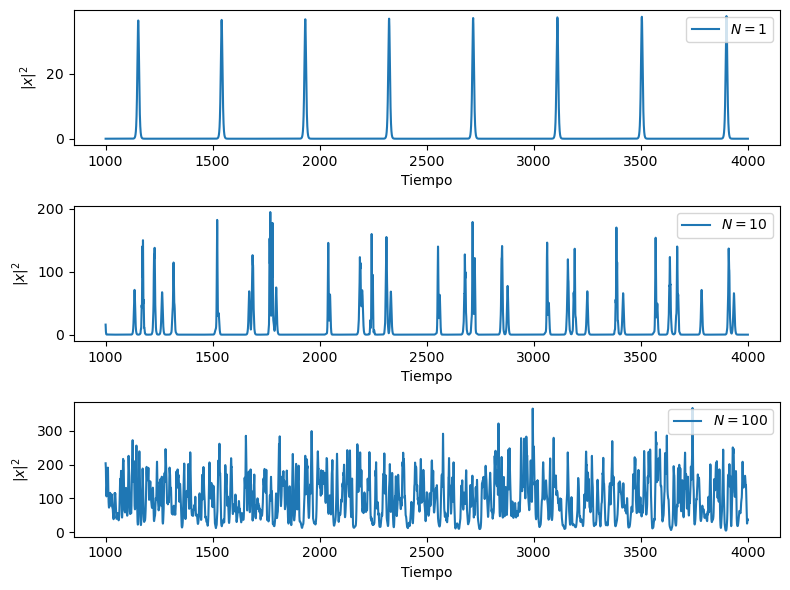

In [10]:
import numpy as np
import matplotlib.pyplot as plt
from numba import njit

@njit(fastmath=True)
def antiHebbian(X_0, W_0, alpha, dt, steps):
    dim = X_0.shape[0]
    X = np.zeros((steps, dim))
    X[0] = X_0
    W = np.copy(W_0) # Usar copy para no modificar el original por error
    I = np.eye(dim)
    
    # Pre-reservamos memoria para las matrices auxiliares para no hacerlo en el bucle
    dWdt = np.zeros((dim, dim))
    outer_X = np.zeros((dim, dim))

    for t in range(1, steps):
        if (10 * t) % steps == 0:
            print("Paso", t, "/", steps)
            
        # Seguro contra explosión numérica (NaN)
        if np.isnan(X[t-1, 0]) or np.isnan(W[0, 0]):
            print("¡Alerta! Inestabilidad numérica detectada. Valores = NaN.")
            break

        # 1. Calculamos dXdt
        dXdt = W @ X[t-1]
        
        # 2. Calculamos el outer product a mano o usando la función, pero 
        # asignándolo eficientemente si es posible. (Numba maneja np.outer, 
        # pero para optimizarlo del todo, evitamos operaciones encadenadas complejas)
        outer_X = np.outer(X[t-1], X[t-1])
        dWdt = alpha * (I - outer_X)

        # 3. Actualizamos X y W
        X[t] = X[t-1] + dt * dXdt
        W = W + dt * dWdt

    return X

# PARÁMETROS REDUCIDOS PARA PRUEBAS (Te recomiendo subir esto poco a poco)
dims = [1, 10, 100] # Cambiado 1000 por 50 para que veas que termina
time = 4000
t_0 = 1000
alpha = 0.001
dt = 0.01
steps = int(time/dt)
s_0 = int(t_0/dt)
eval_steps = int((time - t_0)/dt)
t_eval = np.linspace(t_0, time, eval_steps)

fig, ax = plt.subplots(len(dims), figsize=(8, 6))
if len(dims) == 1:
    ax = [ax] # Asegurar que sea iterable si solo hay 1 dimensión

for i, N in enumerate(dims):
    print(f"\n--- Iniciando N = {N} ---")
    W_0 = np.random.normal(0, 1/np.sqrt(N), (N, N))
    X_0 = np.random.normal(0, 1/np.sqrt(N), N)

    X = antiHebbian(X_0, W_0, alpha, dt, steps)
    print(f"N = {N} simulado, procesando gráfica...")
    
    ax[i].plot(t_eval, np.linalg.norm(X[s_0:steps], axis=1)**2, label=fr"$N=${N}")
    ax[i].set_ylabel(r"$|x|^2$")
    ax[i].set_xlabel("Tiempo")
    ax[i].legend(loc='upper right')
plt.tight_layout()
plt.savefig("Figures/Norma X diferentes dimensiones.pdf")
plt.show()

## Atractor

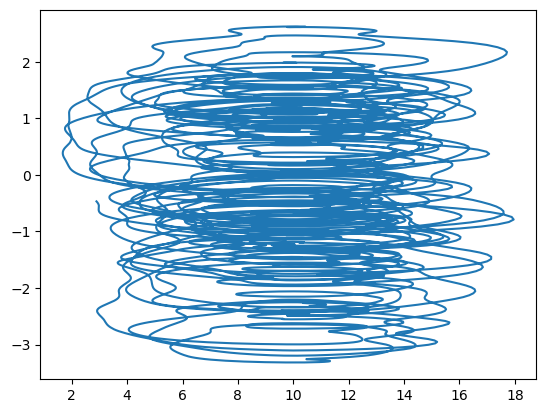

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp

def ODE_system(t, y, dim, alpha):
    X = y[:dim]
    W = y[dim:].reshape((dim, dim))

    dim = np.shape(X)[0]
    dWdt = alpha * (np.eye(dim) - np.outer(X, X))
    dXdt = W @ X

    return np.concatenate([dXdt, dWdt.flatten()])

N = 100
time = 4000
alpha = 0.001
t_eval = np.linspace(2000, time, 10000)


W_0 = np.random.normal(0, 1/np.sqrt(N), (N, N))
X_0 = np.random.normal(0, 1/np.sqrt(N), N)

y_0 = np.concatenate([X_0, W_0.flatten()])
solution = solve_ivp(ODE_system, [0, time], y0=y_0, args=[N, alpha], t_eval=t_eval, method='DOP853')

X = solution.y[:N, :].transpose()
W = solution.y[N:, :].reshape((N, N, -1)).transpose(2, 0, 1)

X_norm = np.linalg.norm(X, axis=1)

W_trace = np.trace(W, axis1=1, axis2=2)

plt.plot(X_norm, W_trace)

plt.show()


## Estudio de autovectores

Paso 40000 / 400000
Paso 80000 / 400000
Paso 120000 / 400000
Paso 160000 / 400000
Paso 200000 / 400000
Paso 240000 / 400000
Paso 280000 / 400000
Paso 320000 / 400000
Paso 360000 / 400000
Calculando autovalores...
Autovalores calculados
Ordenando autovalores
Autovalores ordenados


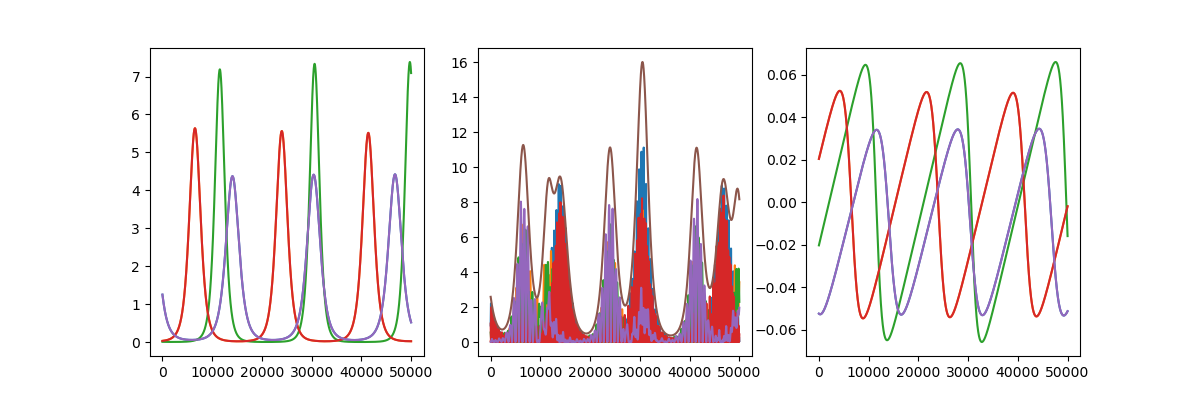

In [46]:
%matplotlib widget
import numpy as np
import matplotlib.pyplot as plt
from numba import njit

@njit(fastmath=True)
def antiHebbian(X_0, W_0, alpha, dt, steps):
    dim = X_0.shape[0]
    X = np.zeros((steps, dim))
    W = np.zeros((steps, dim, dim))
    X[0] = X_0
    W[0] = W_0
    I = np.eye(dim)
    
    # Pre-reservamos memoria para las matrices auxiliares para no hacerlo en el bucle
    dWdt = np.zeros((dim, dim))
    outer_X = np.zeros((dim, dim))

    for t in range(1, steps):
        if (10 * t) % steps == 0:
            print("Paso", t, "/", steps)
            
        # Seguro contra explosión numérica (NaN)
        if np.isnan(X[t-1, 0]) or np.isnan(W[t-1, 0, 0]):
            print("¡Alerta! Inestabilidad numérica detectada. Valores = NaN.")
            break

        # 1. Calculamos dXdt
        dXdt = W[t-1] @ X[t-1]
        
        # 2. Calculamos el outer product a mano o usando la función, pero 
        # asignándolo eficientemente si es posible. (Numba maneja np.outer, 
        # pero para optimizarlo del todo, evitamos operaciones encadenadas complejas)
        outer_X = np.outer(X[t-1], X[t-1])
        dWdt = alpha * (I - outer_X)

        # 3. Actualizamos X y W
        X[t] = X[t-1] + dt * dXdt
        W[t] = W[t-1] + dt * dWdt

    return X, W

def track_eigen_inertia(all_evals, all_evecs):
    """
    Ordena autovalores y autovectores a lo largo del tiempo basándose EXCLUSIVAMENTE
    en la inercia (predicción lineal) de la trayectoria de los autovalores.
    
    all_evals: array (T, N) de autovalores complejos.
    all_evecs: array (T, N, N) de autovectores complejos.
    """
    T, N = all_evals.shape
    tracked_evals = np.zeros((T, N), dtype=np.complex128)
    tracked_evecs = np.zeros((T, N, N), dtype=np.complex128)
    
    if T == 0:
        return tracked_evals, tracked_evecs
        
    # --- Paso t=0: Ordenar por parte imaginaria ---
    idx_0 = np.argsort(all_evals[0].imag)
    tracked_evals[0] = all_evals[0][idx_0]
    tracked_evecs[0] = all_evecs[0][:, idx_0]
    
    if T == 1:
        return tracked_evals, tracked_evecs

    # --- Paso t=1: Distancia pura (sin inercia aún) ---
    curr_evals = all_evals[1]
    prev_evals = tracked_evals[0]
    
    cost_matrix = np.abs(prev_evals[:, None] - curr_evals[None, :])
    _, col_ind = linear_sum_assignment(cost_matrix)
    
    tracked_evals[1] = curr_evals[col_ind]
    tracked_evecs[1] = all_evecs[1][:, col_ind]

    # --- Pasos t >= 2: Inercia / Predicción Lineal ---
    for t in range(2, T):
        curr_evals = all_evals[t]
        
        # 1. Calcular la velocidad (delta) del paso anterior
        velocidad = tracked_evals[t-1] - tracked_evals[t-2]
        
        # 2. Predecir la posición esperada en el paso actual
        prediccion = tracked_evals[t-1] + velocidad
        
        # 3. Matriz de costo: Distancia entre la PREDICCIÓN y los valores ACTUALES
        cost_matrix = np.abs(prediccion[:, None] - curr_evals[None, :])
        
        # 4. Asignación óptima con el algoritmo húngaro
        _, col_ind = linear_sum_assignment(cost_matrix)        
        
        # 5. Guardar los resultados ordenados
        tracked_evals[t] = curr_evals[col_ind]
        tracked_evecs[t, :, :] = all_evecs[t][:, col_ind]
        
    return tracked_evals, tracked_evecs

dim = 5
time = 4000
t_0 = 3500
alpha = 0.001
dt = 0.01
steps = int(time/dt)
s_0 = int(t_0/dt)
eval_steps = int((time - t_0)/dt)
t_eval = np.linspace(t_0, time, eval_steps)

W_0 = np.random.normal(0, 1/np.sqrt(dim), (dim, dim))
W_0 = (W_0 - np.transpose(W_0))/2

X_0 = np.random.normal(0, 1/np.sqrt(dim), dim)

full_X, full_W = antiHebbian(X_0, W_0, alpha, dt, steps)

# Tomamos solo los datos de 2000 para adelante
W = full_W[s_0:]
X = full_X[s_0:]

print("Calculando autovalores...")
eigenvalues, eigenvectors = np.linalg.eig(W)
print("Autovalores calculados")
print("Ordenando autovalores")
tracked_evals, r_tracked_evecs = track_eigen_inertia(eigenvalues, eigenvectors)
print("Autovalores ordenados")


l_tracked_evecs = np.linalg.inv(r_tracked_evecs)
projections = np.einsum('tij,tj->ti', l_tracked_evecs, X)
plt.close()
fig, ax = plt.subplots(ncols=3, figsize=(12,4))
ax[0].plot(np.abs(projections)**2)
ax[1].plot(X**2)
ax[1].plot(np.linalg.norm(X, axis=1)**2)
ax[2].plot(tracked_evals.real)

plt.show()